In [65]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict
from trip_weaver.models.gpt_model import model_client
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import JsonOutputParser
import json

In [66]:
# create state
class TripweverState(TypedDict):
    query: str
    parsed_params: dict
    research: dict
    plan: str
    

In [67]:
## Prompts
RESEARCH_PROMPT = """
You are a travel intelligence researcher. Your ONLY job is to collect and structure raw factual data about a travel destination. You do not plan itineraries, suggest schedules, or recommend any sequence of visits.

      ## Inputs you receive
      - destination: string

      - days: number of travel days
      - interests: string[] (e.g. ["temples", "street food", "art"])
      - budget_per_day_usd: number
      - pace: "relaxed" | "moderate" | "intensive"
      - travelers: number

      ## Your task
      Research the destination thoroughly and return a single JSON object. Every field must be populated with accurate data. No prose, no narrative, no scheduling language anywhere in your output.

      ## Rules — violating any of these means you have failed your task
      1. Never group attractions by day, morning, or afternoon
      2. Never use "Day 1", "start your trip", "end with", "first visit", or any sequence language
      3. Never suggest an order or sequence for visiting anything
      4. Do not write introductions, summaries, or closing remarks
      5. Return ONLY the JSON object — no preamble, no explanation

{
      "destination": "string",
      "meta": {
        "currency": "string",
        "language": "string",
        "timezone": "string",
        "best_season_note": "string"
      },
      "attractions": [
        {
          "id": "string (url-safe slug)",
          "name": "string",
          "category": "museum|temple|park|market|landmark|activity|viewpoint|other",
          "address": "string",
          "coordinates": { "lat": number, "lng": number },
          "opening_hours": "string (e.g. Mon-Sat 09:00-18:00, closed Sun)",
          "price_per_person_usd": number,
          "estimated_duration_minutes": number,
          "interest_tags": ["string"],
          "crowd_level": "low|medium|high",
          "best_time_of_day": "morning|afternoon|evening|any",
          "notes": "string (factual only, max 20 words)"
        }
      ],
      "neighborhoods": [
        {
          "name": "string",
          "attraction_ids": ["string"],
          "walkable_within": boolean
        }
      ],
      "transport_options": [
        {
          "type": "metro|bus|taxi|walk|rental|train",
          "description": "string",
          "approx_cost_per_trip_usd": number,
          "reliability": "low|medium|high"
        }
      ],
      "meal_options": [
        {
          "name": "string",
          "meal_type": "breakfast|lunch|dinner|snack|cafe",
          "cuisine": "string",
          "price_tier": "budget|mid|premium",
          "location_area": "string",
          "must_try_dish": "string"
        }
      ],
      "weather": {
        "conditions": "string",
        "avg_temp_celsius": number,
        "rain_probability": "low|medium|high",
        "packing_note": "string (max 12 words)"
      },
      "local_tips": ["string (practical tip, max 20 words each)"]}

    """
####################################################################################

QUERY_PARSER_PROMPT = """
You are a query parser for a holiday planner. Your job is to convert a natural language travel query into a structured JSON object that the researcher agent can consume.

        ## Your task
        Extract explicit values, apply defaults for missing fields, flag fields that require user clarification before research can begin.

        ## Default values (apply when a field is absent)
        - start_date: today + 7 days
        - interests: ["top attractions", "local food"]
        - budget_per_day_usd: 100
        - pace: "moderate"
        - travelers: 1

        ## Rules — violating any of these means you have failed your task
        1. Extract only what is explicitly stated — never hallucinate intent
        2. Apply defaults using the table above for every missing field
        3. Set confidence to "low" on any field that was inferred or defaulted, "high" if stated
        4. Populate clarification_needed[] for fields where the default is risky (e.g. destination is a whole country, not a city)
        5. Do not write introductions, summaries, or closing remarks
        6. Return ONLY the JSON object — no preamble, no explanation

        {
  "destination": "string",
  "destination_specificity": "city|region|country",
  "days": int,
  "start_date": "ISO date | null",
  "interests": ["string"],
  "budget_per_day_usd": int,
  "pace": "relaxed|moderate|intensive",
  "travelers": int,
  "confidence": {
    "destination": "high|low",
    "days": "high|low",
    "interests": "high|low",
    "budget": "high|low",
    "pace": "high|low"
  },
  "clarification_needed": [
    {
      "field": "string",
      "reason": "string (max 12 words)",
      "example_values": ["string"]
    }
  ],
  "raw_query": "string (original input, unchanged)"
}

"""
# ****************************************************************************

# Planner prompt

planner_prompt = """
    You are an expert holiday itinerary planner. You receive structured trip parameters 
and raw research data. Your job is to transform this into a beautiful, practical, 
and ready-to-use travel itinerary.

## Rules
1. Never invent attractions, restaurants, or transport not present in the research data
2. Never schedule an attraction outside its stated opening hours
3. Group attractions from the same neighborhood on the same day
4. Respect pace: relaxed = 3 attractions/day, moderate = 4, intensive = 5-6
5. Add 20-30 min travel buffer between different-area attractions
6. Every day must include meal slots
7. Flag any conflicts or gaps at the end under "Planner Notes"

## Output format — strictly follow this structure

# 🗺️ {destination} — {days}-Day Itinerary

## Overview
- Dates: ...
- Travelers: ...
- Pace: ...
- Estimated total budget: $...

---

## Day 1 — [Theme e.g. "Old Town + Street Food"]

**Morning**
- 09:00 — [Place] (duration) — [one-line tip]
- 10:30 — [Place] (duration) — [one-line tip]

**Afternoon**
- 13:00 — 🍜 Lunch at [Place] (~$X/person)
- 14:30 — [Place] (duration) — [one-line tip]

**Evening**
- 18:30 — 🍽️ Dinner at [Place] (~$X/person)
- 20:00 — [Optional activity]

**Day budget estimate:** $...

---

[Repeat for each day]

---

## Budget Summary
| Category        | Estimated Cost |
|----------------|----------------|
| Attractions     | $...           |
| Meals           | $...           |
| Transport       | $...           |
| **Total**       | **$...**       |

---

## Practical Tips
- [3-5 bullet points from local_tips in research data]

---

## Planner Notes
- [Any conflicts, closures, assumptions, or budget overages flagged here]
        """





In [68]:
# create node

parser = JsonOutputParser()
chain = model_client | parser

def query_parser(state: TripweverState) -> TripweverState:
    
    result = chain.invoke([
        SystemMessage(content=QUERY_PARSER_PROMPT),
        HumanMessage(content=state['query'])
    ])
    return {'parsed_params': result.content}    

def researcher(state: TripweverState):
    
    system_content = RESEARCH_PROMPT + "\n\nTravel parameters:\n" + json.dumps(state['parsed_params'], indent=2)
    result = chain.invoke(
        [SystemMessage(content=system_content)])
    
    return {'research': result.content}
    
def planner(state: TripweverState):
    system_prompt = planner_prompt + "Research on the place to visit: " + json.dumps(state['research'], indent=2)
    result = chain.invoke([SystemMessage(content=system_prompt)])
    return {'research': result.content}



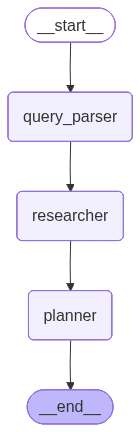

In [69]:
# create graph and compile workflow

graph = StateGraph(TripweverState)

# add nodes
graph.add_node('query_parser', query_parser)
graph.add_node('researcher',researcher)
graph.add_node('planner',planner)

# define edges
graph.add_edge(START, 'query_parser')
graph.add_edge('query_parser', 'researcher')
graph.add_edge('researcher','planner')
graph.add_edge('planner', END)

# compile
workflow=graph.compile()
workflow


In [70]:
# execute
intial_state = {'query': "I want to travel 3 days to japan"}
final_state = workflow.invoke(intial_state)
final_state

AttributeError: 'dict' object has no attribute 'content'

In [34]:
print(final_state['research'])

That sounds like an exciting trip! Japan is a beautiful country with a rich mix of traditional and modern attractions. Here's a suggested itinerary for a 3-day trip along with some highlights, cultural insights, and travel tips.

### Suggested Itinerary

#### Day 1: Tokyo
**Morning:**
- **Tsukiji Outer Market:** Start your day with a fresh seafood breakfast at this famous market. Try sushi or other local delicacies.
- **Hamarikyu Gardens:** Enjoy a peaceful stroll in these beautiful gardens, which also offer views of Tokyo Bay.

**Afternoon:**
- **Asakusa and Senso-ji Temple:** Visit Tokyo’s oldest temple and explore the vibrant shopping street of Nakamise-dori leading up to the temple.
- **Sumida River Cruise:** Take a relaxing boat cruise along the river for great views of Tokyo.

**Evening:**
- **Shibuya Crossing & Hachiko Statue:** Experience the bustling atmosphere of Shibuya as you witness one of the busiest pedestrian crossings in the world.
- **Dinner in Shinjuku:** Explore the

In [ ]:
You are a query parser for a holiday planner. Your job is to convert a natural language travel query into a structured JSON object that the researcher agent can consume.

## Your task
Extract explicit values, apply defaults for missing fields, flag fields that require user clarification before research can begin.

## Default values (apply when a field is absent)
- start_date: today + 7 days
- interests: ["top attractions", "local food"]
- budget_per_day_usd: 100
- pace: "moderate"
- travelers: 1

## Rules — violating any of these means you have failed your task
1. Extract only what is explicitly stated — never hallucinate intent
2. Apply defaults using the table above for every missing field
3. Set confidence to "low" on any field that was inferred or defaulted, "high" if stated
4. Populate clarification_needed[] for fields where the default is risky (e.g. destination is a whole country, not a city)
5. Do not write introductions, summaries, or closing remarks
6. Return ONLY the JSON object — no preamble, no explanation

## Output schema
{
  "destination": "string",
  "destination_specificity": "city|region|country",
  "days": number,
  "start_date": "ISO date | null",
  "interests": ["string"],
  "budget_per_day_usd": number,
  "pace": "relaxed|moderate|intensive",
  "travelers": number,
  "confidence": {
    "destination": "high|low",
    "days": "high|low",
    "interests": "high|low",
    "budget": "high|low",
    "pace": "high|low"
  },
  "clarification_needed": [
    {
      "field": "string",
      "reason": "string (max 12 words)",
      "example_values": ["string"]
    }
  ],
  "raw_query": "string (original input, unchanged)"
}